<a href="https://colab.research.google.com/github/Aryaaajha/UAE_Real_Estate_Analysis/blob/main/UAE_Real_Estate_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **UAE Real Estate Analysis**

In [ ]:
import pandas as pd
import numpy as np

**Loading the Data**

In [ ]:
df=pd.read_csv('dubai_properties.csv')

In [ ]:
df.describe(include='all')

,Address,Rent,Beds,Baths,Type,Area_in_sqft,Rent_per_sqft,Rent_category,Frequency,Furnishing,Purpose,Posted_date,Age_of_listing_in_days,Location,City,Latitude,Longitude
count,73742,7.374200e+04,73742.000000,73742.000000,73742,73742.000000,73742.000000,73742,73742,73742,73742,73742,73742.000000,73742,73742,73023.000000,73023.000000
unique,4515,NaN,NaN,NaN,9,NaN,NaN,3,1,2,1,544,NaN,441,8,NaN,NaN
top,"Khalifa City, Abu Dhabi",NaN,NaN,NaN,Apartment,NaN,NaN,Medium,Yearly,Unfurnished,For Rent,03-04-2024,NaN,Al Reem Island,Dubai,NaN,NaN
freq,2300,NaN,NaN,NaN,56534,NaN,NaN,25088,73742,58062,73742,1781,NaN,3668,34250,NaN,NaN
mean,NaN,1.479250e+05,2.162811,2.650213,NaN,2054.053552,88.057754,NaN,NaN,NaN,NaN,NaN,74.261547,NaN,NaN,24.918929,55.053133
std,NaN,3.069658e+05,1.578155,1.632997,NaN,3003.919252,66.534400,NaN,NaN,NaN,NaN,NaN,72.346767,NaN,NaN,0.569356,0.653722
min,NaN,0.000000e+00,0.000000,1.000000,NaN,74.000000,0.000000,NaN,NaN,NaN,NaN,NaN,11.000000,NaN,NaN,15.175847,43.351928
25%,NaN,5.499900e+04,1.000000,2.000000,NaN,850.000000,39.977778,NaN,NaN,NaN,NaN,NaN,30.000000,NaN,NaN,24.493598,54.607372
50%,NaN,9.800000e+04,2.000000,2.000000,NaN,1334.000000,71.428571,NaN,NaN,NaN,NaN,NaN,52.000000,NaN,NaN,25.078641,55.238209
75%,NaN,1.700000e+05,3.000000,3.000000,NaN,2130.000000,118.483412,NaN,NaN,NaN,NaN,NaN,95.000000,NaN,NaN,25.197978,55.367138


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73742 entries, 0 to 73741
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Address                 73742 non-null  object 
 1   Rent                    73742 non-null  int64  
 2   Beds                    73742 non-null  int64  
 3   Baths                   73742 non-null  int64  
 4   Type                    73742 non-null  object 
 5   Area_in_sqft            73742 non-null  int64  
 6   Rent_per_sqft           73742 non-null  float64
 7   Rent_category           73742 non-null  object 
 8   Frequency               73742 non-null  object 
 9   Furnishing              73742 non-null  object 
 10  Purpose                 73742 non-null  object 
 11  Posted_date             73742 non-null  object 
 12  Age_of_listing_in_days  73742 non-null  int64  
 13  Location                73742 non-null  object 
 14  City                    73742 non-null

**Data Cleaning**

In [ ]:
df.isnull().sum()

,0
Address,0
Rent,0
Beds,0
Baths,0
Type,0
Area_in_sqft,0
Rent_per_sqft,0
Rent_category,0
Frequency,0
Furnishing,0


In [ ]:
#Fill missing coordinates
df['Latitude'] = df.groupby('City')['Latitude'].transform(lambda x: x.fillna(x.mean()))
df['Longitude'] = df.groupby('City')['Longitude'].transform(lambda x: x.fillna(x.mean()))

In [ ]:
# Convert to datetime
df['Posted_date'] = pd.to_datetime(df['Posted_date'],dayfirst=True)

In [ ]:
# Drop columns with zero variance
df.drop(columns=['Frequency','Purpose'],inplace=True)

In [ ]:
# Drop '0' Rent houses
df = df[df['Rent'] > 0]

In [ ]:
# Convert column name to lower string
df.columns = df.columns.str.lower()

In [ ]:
df.columns

Index(['address', 'rent', 'beds', 'baths', 'type', 'area_in_sqft',
       'rent_per_sqft', 'rent_category', 'furnishing', 'posted_date',
       'age_of_listing_in_days', 'location', 'city', 'latitude', 'longitude'],
      dtype='object')

In [ ]:
# Delete duplicate entries
df = df.drop_duplicates()

In [ ]:
# Handle outliers
for col in ['rent', 'area_in_sqft']:
    lower_limit = df[col].quantile(0.001)
    upper_limit = df[col].quantile(0.99)
    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

In [ ]:
df['posted_month'] = df['posted_date'].dt.month_name()
df['posted_year'] = df['posted_date'].dt.year

In [ ]:
df.to_csv('cleaned_dubai_properties.csv')

**KPI Requirements**

In [ ]:
# Median Rent
median_rent = df['rent'].median()
print(f"Median rent :{median_rent:,.0f} AED")

# Average Rent
avg_rent = df['rent'].mean()
print(f"Average rent :{avg_rent:,.0f} AED")

# Average Price per Sqft
avg_price = df['rent_per_sqft'].mean()
print(f"Average price per sqft :{avg_price:,.0f} AED")

# What are people mostly listing? (Apartments vs Villas)
top_property_type = df['type'].value_counts().idxmax()
print(f"Top Property Type: {top_property_type}")

# Which cities have the most activity?
city_distribution = df['city'].value_counts()
print("\nListings per City:")
print(city_distribution)


Median rent :95,000 AED
Average rent :129,177 AED
Average price per sqft :87 AED
Top Property Type: Apartment

Listings per City:
city
Dubai             33265
Abu Dhabi         23047
Sharjah            9366
Ajman              4628
Al Ain             1034
Ras Al Khaimah      804
Umm Al Quwain        61
Fujairah             27
Name: count, dtype: int64


In [ ]:
top_locations = df['location'].value_counts().head(10)

print("--- Top 10 Locations by Supply ---")
print(top_locations)

--- Top 10 Locations by Supply ---
location
Al Reem Island                   3662
Jumeirah Village Circle (JVC)    3115
Downtown Dubai                   2965
Khalifa City                     2703
Dubai Marina                     2570
Business Bay                     2146
Muwailih Commercial              2054
Mohammed Bin Zayed City          2018
Al Raha Beach                    1808
Dubai Creek Harbour              1735
Name: count, dtype: int64


**Data Visualization**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

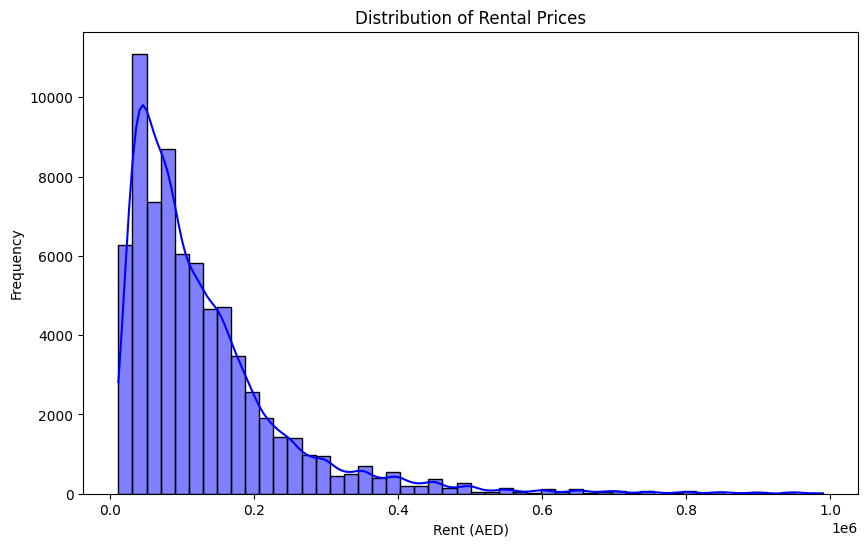

In [ ]:
#Distribution of Rent
plt.figure(figsize=(10,6))
sns.histplot(df['rent'],bins=50, kde=True, color='blue')
plt.title('Distribution of Rental Prices')
plt.xlabel('Rent (AED)')
plt.ylabel('Frequency')
plt.show()

/tmp/ipython-input-161/1282278621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='type',y='rent', data=df, palette='viridis')


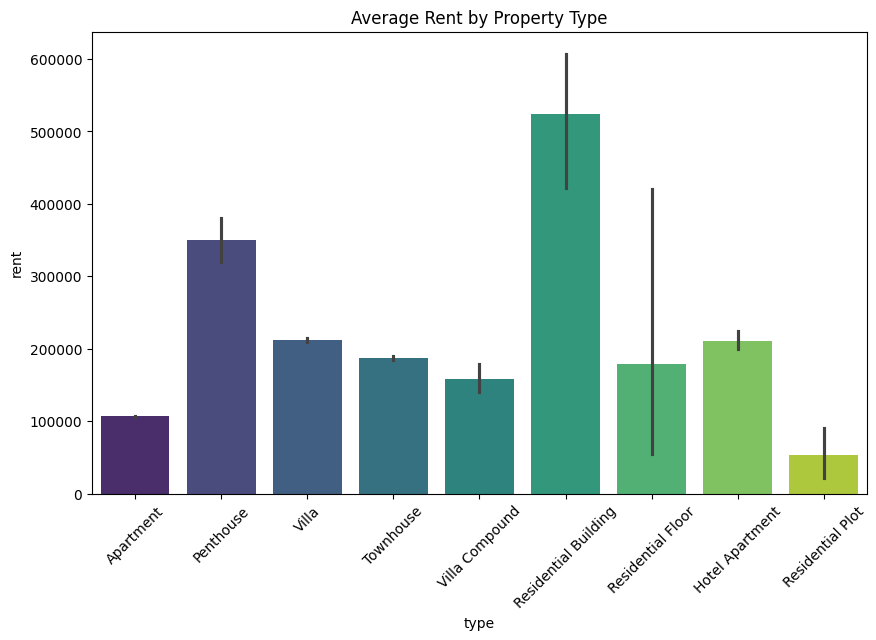

In [ ]:
# Calculate average rent per type and plot
plt.figure(figsize=(10,6))
sns.barplot(x='type',y='rent', data=df, palette='viridis')
plt.title('Average Rent by Property Type')
plt.xticks(rotation=45)
plt.show()

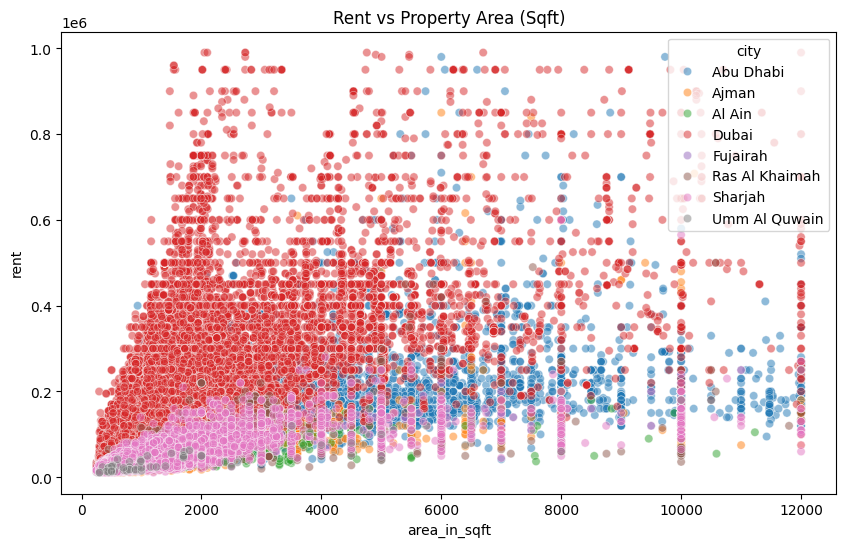

In [ ]:
# Relationship Between Area and Rent
plt.figure(figsize=(10,6))
sns.scatterplot(x='area_in_sqft',y='rent', hue='city',data=df, alpha=0.5)
plt.title('Rent vs Property Area (Sqft)')
plt.show()

/tmp/ipython-input-161/3487885297.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='furnishing',y='rent',data=df, palette='Set2')


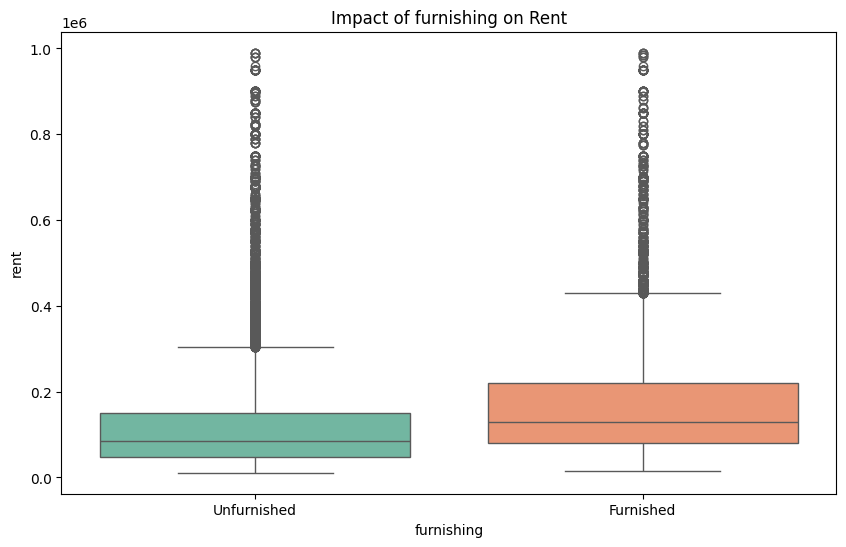

In [ ]:
#Furnishing Impact
plt.figure(figsize=(10,6))
sns.boxplot(x='furnishing',y='rent',data=df, palette='Set2')
plt.title('Impact of furnishing on Rent')
plt.show()

/tmp/ipython-input-161/4292334204.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='rent', data=df, palette='magma', errorbar=None)


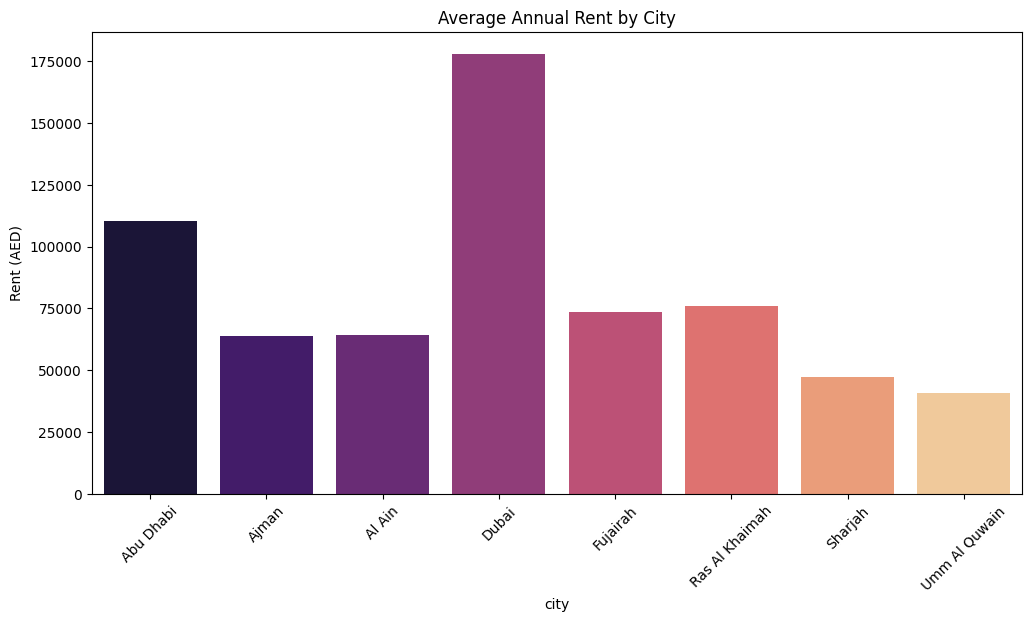

In [ ]:
# Using barplot to show the average rent per city
plt.figure(figsize=(12, 6))
sns.barplot(x='city', y='rent', data=df, palette='magma', errorbar=None)
plt.title('Average Annual Rent by City')
plt.ylabel('Rent (AED)')
plt.xticks(rotation=45)
plt.show()

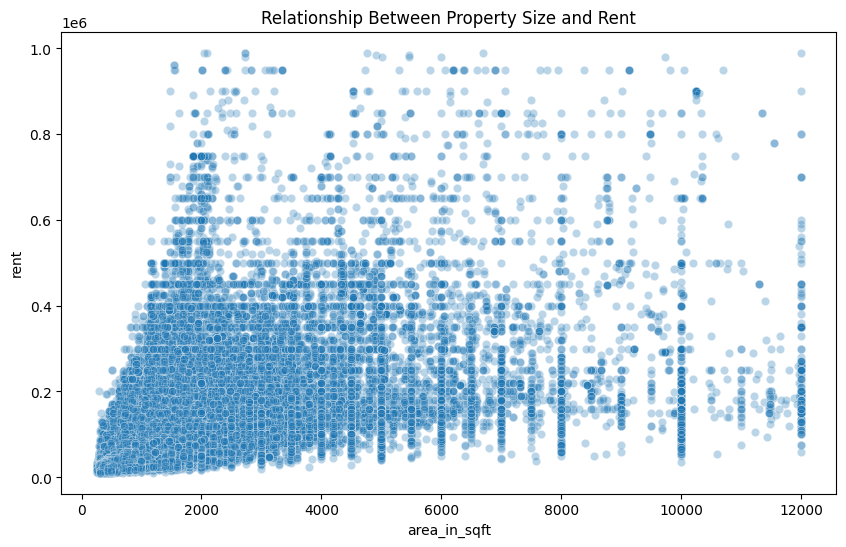

In [ ]:
# Scatter plot shows the relationship between size and price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='area_in_sqft', y='rent', data=df, alpha=0.3)
plt.title('Relationship Between Property Size and Rent')
plt.show()